In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
or_data = pd.DataFrame()
xor_data = pd.DataFrame()
and_data = pd.DataFrame()

In [14]:
or_data ["input1"] = [1,1,0,0]
or_data ["input2"] = [1,0,1,0]
or_data ["output"] = [1,1,1,0]

In [15]:
xor_data ["input1"] = [1,1,0,0]
xor_data ["input2"] = [1,0,1,0]
xor_data ["output"] = [0,1,1,0]

In [16]:
and_data ["input1"] = [1,1,0,0]
and_data ["input2"] = [1,0,1,0]
and_data ["output"] = [1,0,0,0]

In [17]:
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

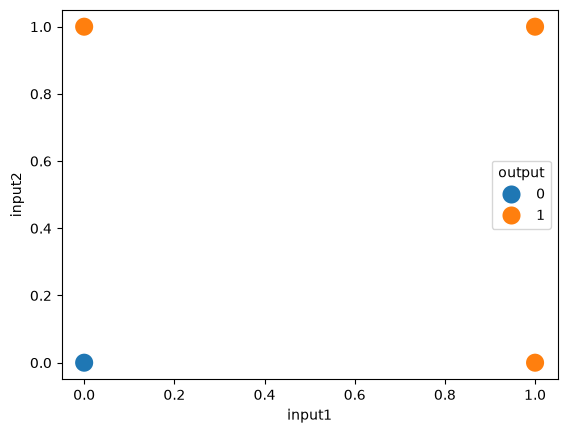

In [19]:
sns.scatterplot(
    data=or_data,
    x="input1",
    y="input2",
    hue="output",
    s=200
)

<Axes: xlabel='input1', ylabel='input2'>

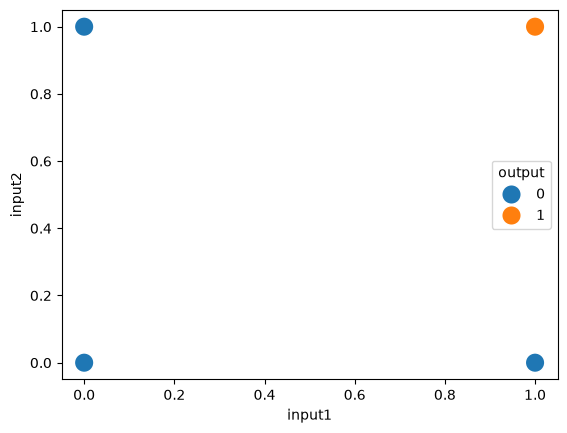

In [20]:
sns.scatterplot(
    data=and_data,
    x="input1",
    y="input2",
    hue="output",
    s=200
)

<Axes: xlabel='input1', ylabel='input2'>

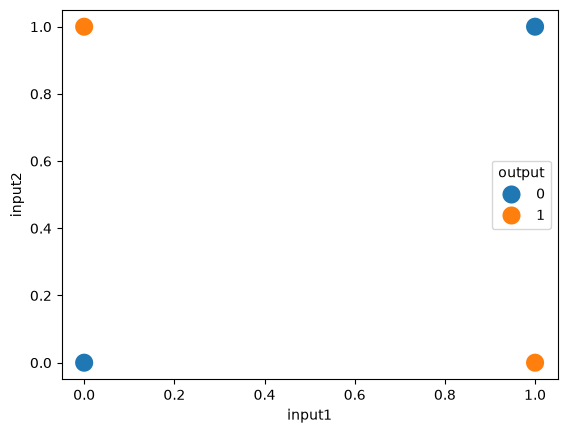

In [21]:
sns.scatterplot(
    data=xor_data,
    x="input1",
    y="input2",
    hue="output",
    s=200
)

In [22]:
from sklearn.linear_model import Perceptron

clf1 = Perceptron()
clf2 = Perceptron()
clf3 = Perceptron()

In [25]:
clf1.fit(
    or_data.iloc[:, 0:2].values,
    or_data.iloc[:, -1].values
)

clf2.fit(
    and_data.iloc[:, 0:2].values,
    and_data.iloc[:, -1].values
)

clf3.fit(
    xor_data.iloc[:, 0:2].values,
    xor_data.iloc[:, -1].values
)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


C:\Users\User\AppData\Local\Temp\ipykernel_12716\1445587573.py:27: RuntimeWarning: invalid value encountered in scalar divide
  m = -(coef[0] / coef[1])
C:\Users\User\AppData\Local\Temp\ipykernel_12716\1445587573.py:28: RuntimeWarning: invalid value encountered in scalar divide
  b = -(intercept / coef[1])


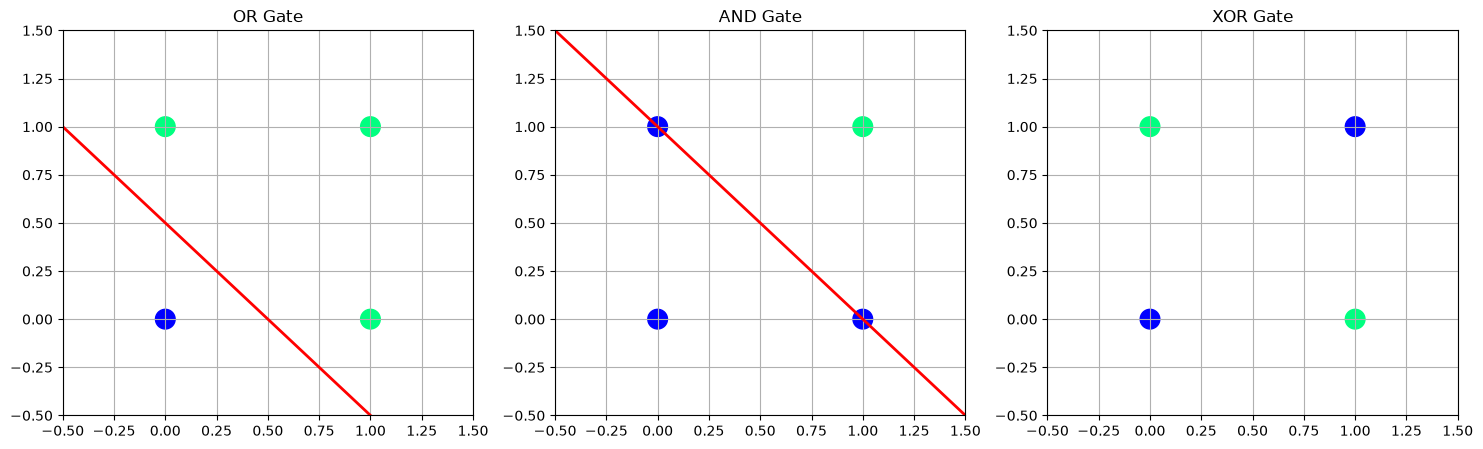

In [26]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (or_data, clf1, "OR Gate"),
    (and_data, clf2, "AND Gate"),
    (xor_data, clf3, "XOR Gate")
]

for i, (data, clf, title) in enumerate(datasets):

    # Scatter Plot
    ax[i].scatter(
        data.iloc[:, 0],
        data.iloc[:, 1],
        c=data.iloc[:, -1],
        cmap="winter",
        s=200
    )

    # Decision Boundary
    coef = clf.coef_[0]
    intercept = clf.intercept_[0]

    m = -(coef[0] / coef[1])
    b = -(intercept / coef[1])

    x = np.linspace(-0.5, 1.5, 100)
    y = m * x + b

    ax[i].plot(x, y, color="red", linewidth=2)

    ax[i].set_title(title)
    ax[i].set_xlim(-0.5, 1.5)
    ax[i].set_ylim(-0.5, 1.5)
    ax[i].grid(True)

plt.show()